In [16]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt 

In [17]:
# Folder containing the CSV files
folder = Path("Results")

# Find all result files
files = sorted(folder.glob("results_*.csv"))

all_dfs = []

for file in files:
    algo_name = file.stem.replace("results_", "")
    df = pd.read_csv(file)
    df["Algorithm"] = algo_name
    all_dfs.append(df)

# Merge into one dataframe
merged_df = pd.concat(all_dfs, ignore_index=True)

# Save merged file
merged_df.to_csv("merged_results.csv", index=False)

print("Merged shape:", merged_df.shape)
print(merged_df.head())

Merged shape: (13185060, 5)
   Timestep  Reward  Cumulative_Reward  Simulation  Algorithm
0         1       0                  0           0  bayes_ucb
1         2       0                  0           0  bayes_ucb
2         3       0                  0           0  bayes_ucb
3         4       0                  0           0  bayes_ucb
4         5       1                  1           0  bayes_ucb


In [18]:
merged_df["CTR"] = merged_df["Cumulative_Reward"] / merged_df["Timestep"]

# 2. Average cumulative reward
avg_cum_reward = (
    merged_df
    .groupby(["Algorithm", "Timestep"], as_index=False)["Cumulative_Reward"]
    .mean()
    .rename(columns={"Cumulative_Reward": "Avg_Cumulative_Reward"})
)

# 3. Average CTR
avg_ctr = (
    merged_df
    .groupby(["Algorithm", "Timestep"], as_index=False)["CTR"]
    .mean()
)

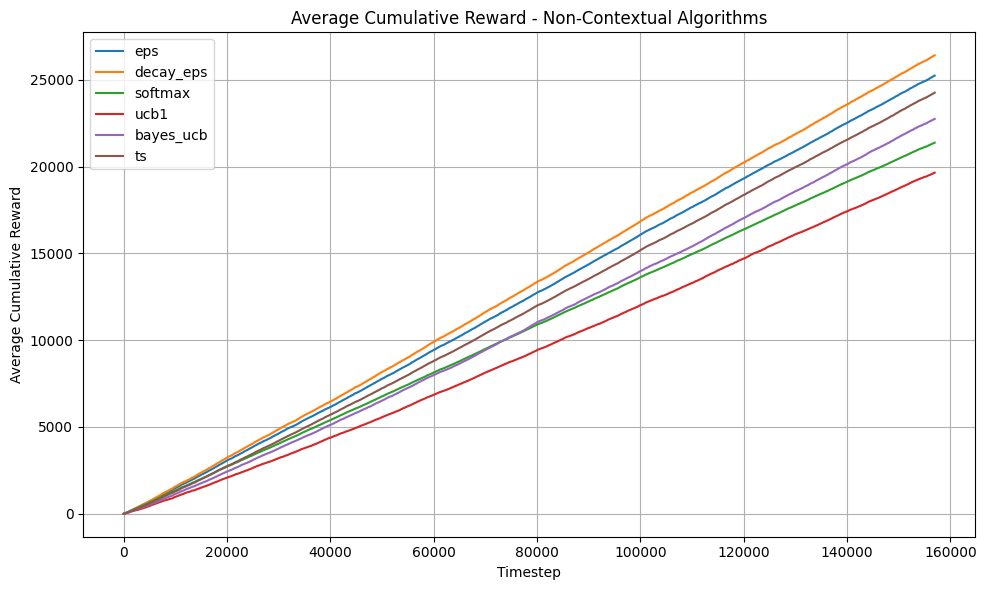

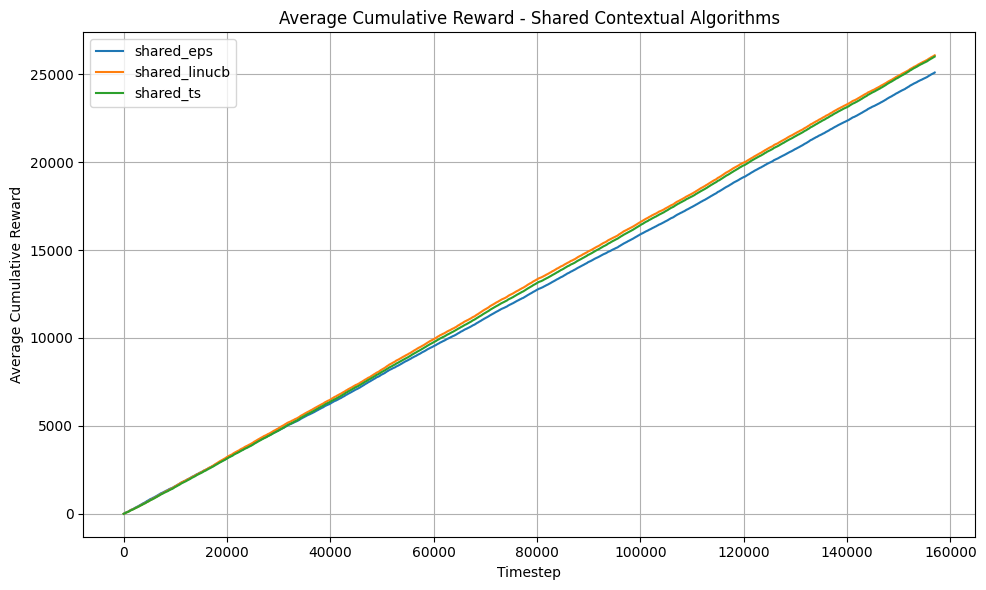

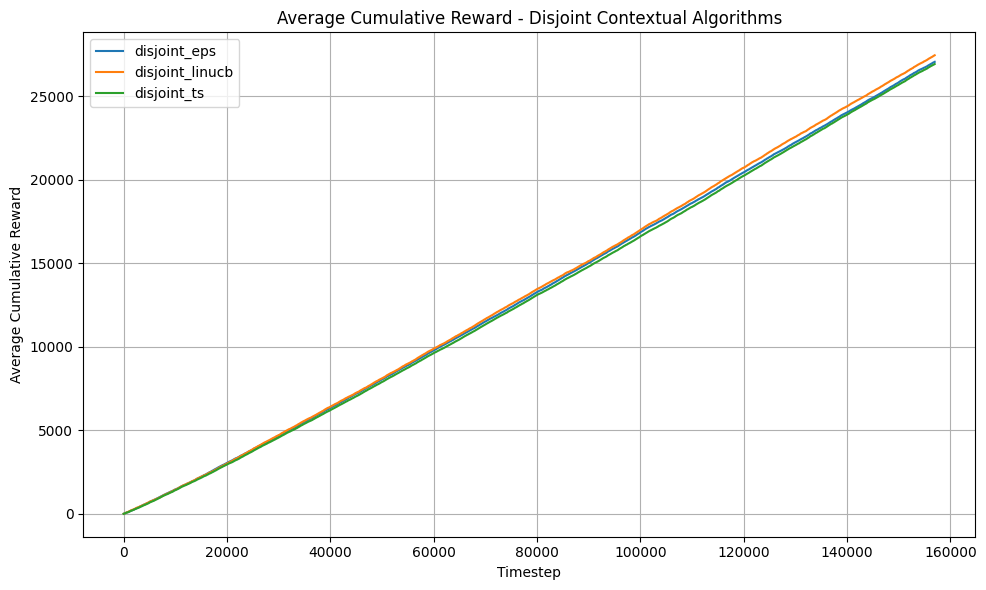

In [19]:
non_contextual = ["eps", "decay_eps", "softmax", "ucb1", "bayes_ucb", "ts"]
shared = ["shared_eps", "shared_linucb", "shared_ts"]
disjoint = ["disjoint_eps", "disjoint_linucb", "disjoint_ts"]

def plot_group(df, algos, title, y_col, y_label):
    plt.figure(figsize=(10, 6))

    for algo in algos:
        grp = df[df["Algorithm"] == algo]
        plt.plot(grp["Timestep"], grp[y_col], label=algo)

    plt.title(title)
    plt.xlabel("Timestep")
    plt.ylabel(y_label)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_group(
    avg_cum_reward,
    non_contextual,
    "Average Cumulative Reward - Non-Contextual Algorithms",
    "Avg_Cumulative_Reward",
    "Average Cumulative Reward"
)

plot_group(
    avg_cum_reward,
    shared,
    "Average Cumulative Reward - Shared Contextual Algorithms",
    "Avg_Cumulative_Reward",
    "Average Cumulative Reward"
)

plot_group(
    avg_cum_reward,
    disjoint,
    "Average Cumulative Reward - Disjoint Contextual Algorithms",
    "Avg_Cumulative_Reward",
    "Average Cumulative Reward"
)

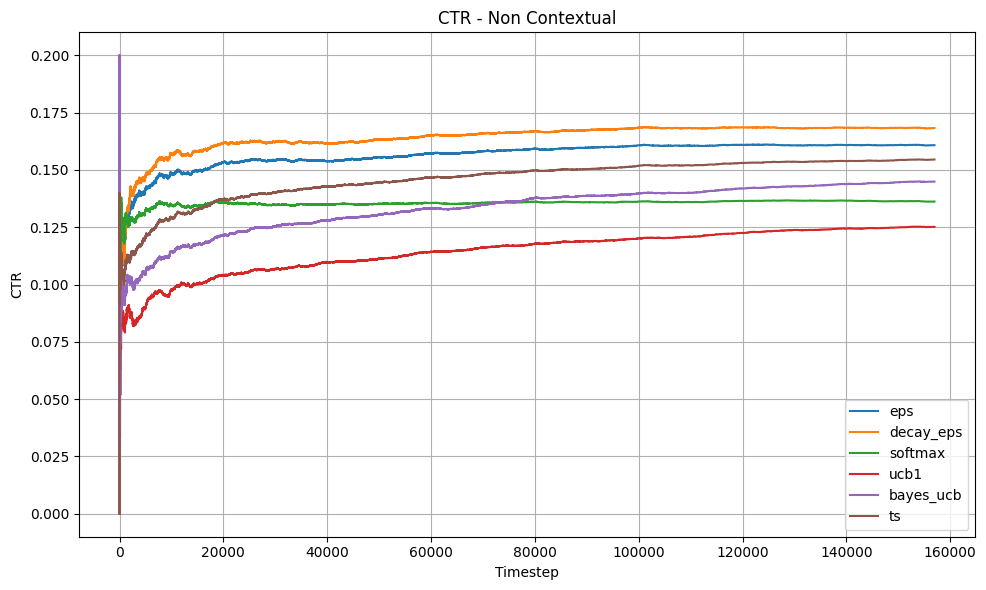

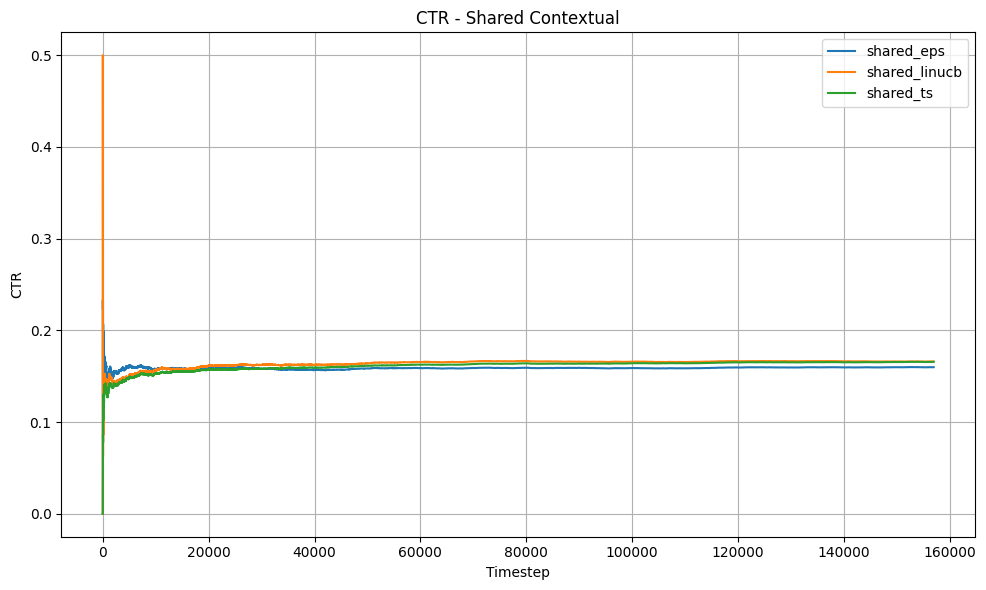

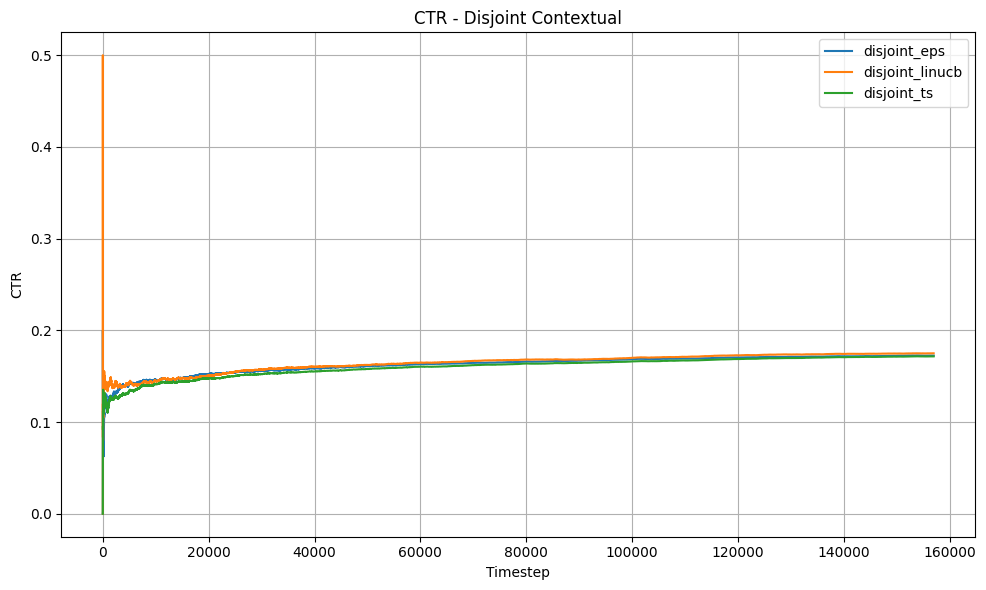

In [20]:
def plot_group(df, algos, title, y_col):
    plt.figure(figsize=(10, 6))
    
    for algo in algos:
        grp = df[df["Algorithm"] == algo]
        plt.plot(grp["Timestep"], grp[y_col], label=algo)

    plt.title(title)
    plt.xlabel("Timestep")
    plt.ylabel(y_col)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_group(avg_ctr, non_contextual, "CTR - Non Contextual", "CTR")
plot_group(avg_ctr, shared, "CTR - Shared Contextual", "CTR")
plot_group(avg_ctr, disjoint, "CTR - Disjoint Contextual", "CTR")


In [21]:
# Sort to ensure correct cumulative order
merged_df = merged_df.sort_values(["Algorithm", "Simulation", "Timestep"])

# Compute CTR directly from merged_df
merged_df["Cumulative_Reward"] = (
    merged_df.groupby(["Algorithm", "Simulation"])["Reward"].cumsum()
)

merged_df["CTR"] = (
    merged_df["Cumulative_Reward"] /
    merged_df.groupby(["Algorithm", "Simulation"]).cumcount().add(1)
)

final_performance = (
    merged_df
    .groupby(["Algorithm", "Simulation"], as_index=False)["CTR"]
    .last()
)

# Aggregate CTR and cumulative rewards across simulations
summary = (
    merged_df
    .sort_values(["Algorithm", "Simulation", "Timestep"])
    .groupby(["Algorithm", "Simulation"])
    .agg(
        Final_CTR=("CTR", "last"),
        Final_CumReward=("Cumulative_Reward", "last")
    )
    .groupby("Algorithm")
    .agg(
        mean_CTR=("Final_CTR", "mean"),
        avg_CumReward=("Final_CumReward", "mean")
    )
    .sort_values(by="mean_CTR", ascending=False)
    .reset_index()
)


print(summary)

          Algorithm  mean_CTR  avg_CumReward
0   disjoint_linucb  0.175001        27469.0
1      disjoint_eps  0.172502        27076.8
2       disjoint_ts  0.171663        26945.1
3         decay_eps  0.168248        26409.1
4     shared_linucb  0.166126        26076.0
5         shared_ts  0.165667        26003.9
6               eps  0.160780        25236.9
7        shared_eps  0.159874        25094.7
8                ts  0.154545        24258.2
9         bayes_ucb  0.144905        22745.0
10          softmax  0.136187        21376.6
11             ucb1  0.125174        19648.0
